## Uppgift: Klustring med K-Means

Ett företag har information om sina kunder, men ingen target-variabel. Företaget vill förstå om det finns olika typer av kunder.

Er uppgift är att använda klustring för att försöka hitta dessa grupper. Arbeta tillsammans i gruppen och diskutera era val.

Vi skapar ett dataset med make_blobs.

In [1]:
from sklearn.datasets import make_blobs

X, _ = make_blobs(
    n_samples=300,
    centers=4,
    cluster_std=1.5,
    random_state=42
)

Undersök: vilket k vi ska välja

* Testa olika värden för k
* Beräkna intertia
* Beräkna silhouette score
* Gör ett silhouette diagram
* Visualisera klustren
* Motivera och argumentera för val av k

Diskutera i gruppen:

* Om inertia säger k=5, medan silhouette score och er visuella bedömning säger k=4 – vilket väljer ni?
* Om vi hittar 5 statistiskt tydliga kluster men experter inom området bara kan tolka 3 av dem – vilket K skulle ni välja?
* Kan ett kluster vara statistiskt bra men ändå vara meningslöst i praktiken?

In [2]:
# 1. Import libraries and create the data
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, silhouette_samples
import matplotlib.pyplot as plt
import numpy as np

# Create the data
X, _ = make_blobs(
    n_samples=300,
    centers=4,
    cluster_std=1.5,
    random_state=42
)

In [3]:
# 2. Test different values of k + calculate inertia and silhouette score
inertias = []
silhouette_scores = []

# Test k from 2 to 8
k_values = range(2, 9)

for k in k_values:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = kmeans.fit_predict(X)

    # Calculate inertia
    inertias.append(kmeans.inertia_)

    # Calculate silhouette score
    score = silhouette_score(X, labels)
    silhouette_scores.append(score)

    print(f"k = {k}, Inertia = {kmeans.inertia_:.2f}, "
          f"Silhouette Score = {score:.3f}")

k = 2, Inertia = 10128.26, Silhouette Score = 0.557
k = 3, Inertia = 2786.74, Silhouette Score = 0.702
k = 4, Inertia = 1251.35, Silhouette Score = 0.691
k = 5, Inertia = 1128.47, Silhouette Score = 0.605
k = 6, Inertia = 1011.00, Silhouette Score = 0.495
k = 7, Inertia = 898.43, Silhouette Score = 0.386
k = 8, Inertia = 822.71, Silhouette Score = 0.327


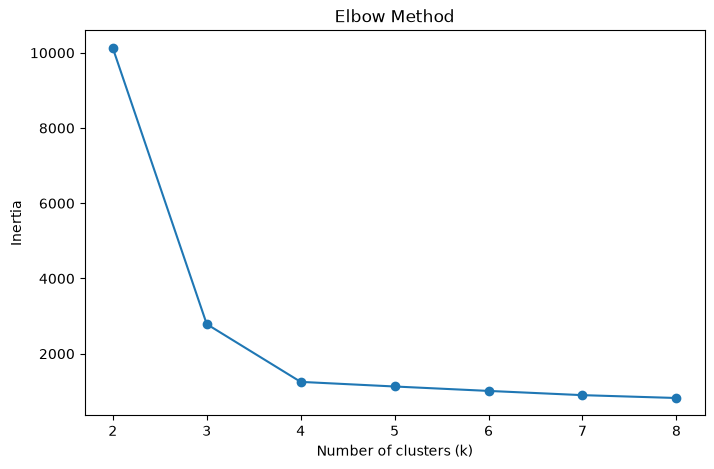

In [4]:
# 3. Plot inertia — the elbow method
plt.figure(figsize=(8, 5))

plt.plot(k_values, inertias, marker="o")

plt.xlabel("Number of clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method")

plt.xticks(list(k_values))
plt.show()

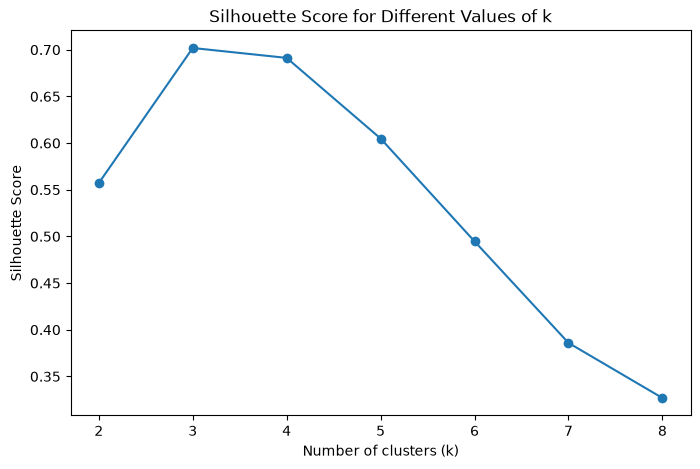

In [5]:
#4. Plot silhouette scores
plt.figure(figsize=(8, 5))

plt.plot(k_values, silhouette_scores, marker="o")

plt.xlabel("Number of clusters (k)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score for Different Values of k")

plt.xticks(list(k_values))
plt.show()

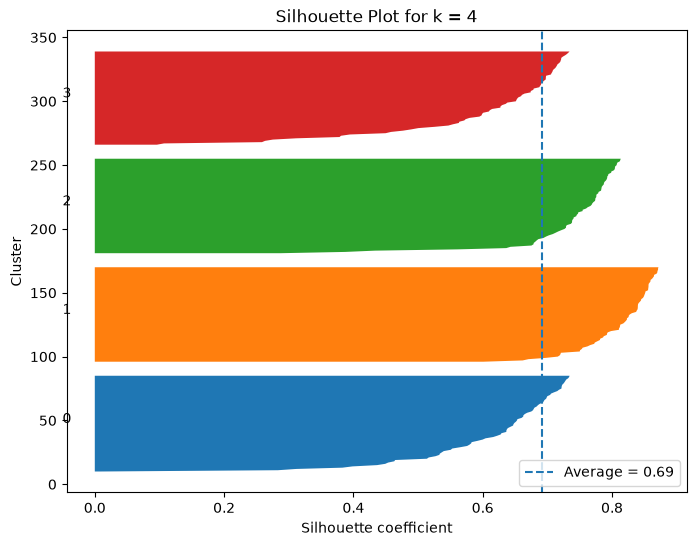

In [9]:
#5. Create a silhouette plot
k = 4

kmeans = KMeans(
    n_clusters=k,
    random_state=42,
    n_init=10
)

labels = kmeans.fit_predict(X)

sample_silhouette_values = silhouette_samples(X, labels)

plt.figure(figsize=(8, 6))

y_lower = 10

for i in range(k):
    # Get silhouette values for cluster i
    cluster_values = sample_silhouette_values[labels == i]
    cluster_values.sort()

    size_cluster = cluster_values.shape[0]
    y_upper = y_lower + size_cluster

    plt.fill_betweenx(
        np.arange(y_lower, y_upper),
        0,
        cluster_values
    )

    plt.text(
        -0.05,
        y_lower + 0.5 * size_cluster,
        str(i)
    )

    y_lower = y_upper + 10

# Average silhouette score
average_score = silhouette_score(X, labels)

plt.axvline(
    average_score,
    linestyle="--",
    label=f"Average = {average_score:.2f}"
)

plt.xlabel("Silhouette coefficient")
plt.ylabel("Cluster")
plt.title(f"Silhouette Plot for k = {k}")
plt.legend()
plt.show()

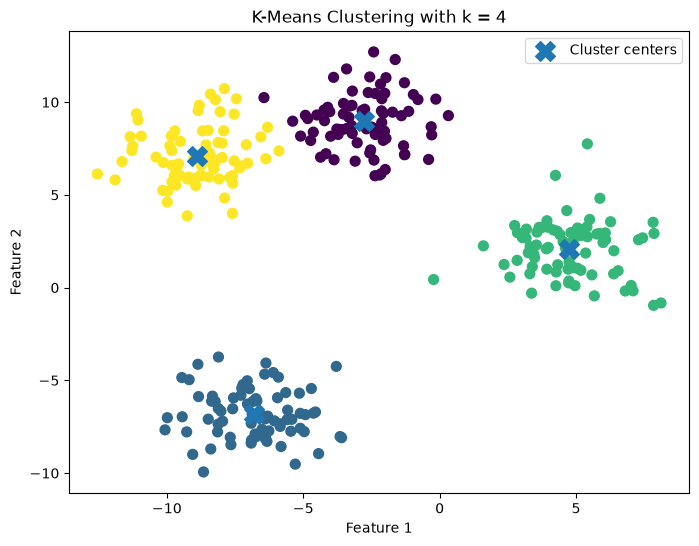

In [10]:
# 6. Visualize the clusters
plt.figure(figsize=(8, 6))

plt.scatter(
    X[:, 0],
    X[:, 1],
    c=labels,
    s=50
)

# Plot cluster centers
plt.scatter(
    kmeans.cluster_centers_[:, 0],
    kmeans.cluster_centers_[:, 1],
    marker="X",
    s=200,
    label="Cluster centers"
)

plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title(f"K-Means Clustering with k = {k}")
plt.legend()
plt.show()

In [11]:
#7. Automatically find the best k based on silhouette score
best_k = k_values[np.argmax(silhouette_scores)]

print("Best k according to silhouette score:", best_k)

Best k according to silhouette score: 3
